# 多步预测对比实验

本实验只验证不同 `HORIZON` 下多步预测的效果，不扩展为完整迁移策略对比。为保持与 `transfer_learning.ipynb` 一致，结果只比较两种策略：

1. **目标域训练（Target-only）**：不使用源域权重，只在目标域训练集上从零训练。
2. **全层微调（Full fine-tune）**：先在源域训练，再在目标域微调全部层。

源域训练只用于为全层微调提供初始权重，不作为结果策略展示。

In [9]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
import joblib

from src import (
    load_data,
    create_sequences,
    LSTMPredictor,
    set_seed,
    evaluate,
    LoadDataset,
    EarlyStopping,
    run_epoch,
    predict,
    mape,
    setup_plot_style,
    BASE_DIR, MODEL_DIR, SCALER_DIR, FIGURES_DIR,
    TARGET_COL, TIME_COL, SEED,
)

# 实验配置
LOOKBACK = 24
BATCH_SIZE = 72
EPOCHS = 100
HIDDEN_SIZE = 128
HORIZON_LIST = [1, 6, 12, 24]

set_seed(SEED)
criterion = nn.L1Loss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
setup_plot_style()

## 数据准备与辅助函数

In [2]:
# 数据路径
SOURCE_TRAIN_PATH = BASE_DIR / 'source_train_std.csv'
TARGET_TRAIN_PATH = BASE_DIR / 'target_train_std.csv'
TARGET_VAL_PATH = BASE_DIR / 'target_val_std.csv'
TARGET_TEST_PATH = BASE_DIR / 'target_test_std.csv'

# 读取源域数据
source_full_df = load_data(SOURCE_TRAIN_PATH).dropna(subset=[TARGET_COL]).reset_index(drop=True)

source_val_ratio = 0.2
source_val_end = int(len(source_full_df) * source_val_ratio)
source_train_df = source_full_df.iloc[:-source_val_end].reset_index(drop=True)
source_val_df = source_full_df.iloc[-source_val_end:].reset_index(drop=True)

# 读取目标域数据
target_train_df = load_data(TARGET_TRAIN_PATH).dropna(subset=[TARGET_COL]).reset_index(drop=True)
target_val_df = load_data(TARGET_VAL_PATH).dropna(subset=[TARGET_COL]).reset_index(drop=True)
target_test_df = load_data(TARGET_TEST_PATH).dropna(subset=[TARGET_COL]).reset_index(drop=True)

# 确定特征列（除时间戳外）
FEATURE_COLS = [c for c in source_train_df.columns if c != TIME_COL]
input_size = len(FEATURE_COLS)

target_scaler = joblib.load(SCALER_DIR / 'target_load_scaler.joblib')


def fit_model(model, train_loader, val_loader, optimizer, lr_scheduler, early_stopping) -> tuple:
    train_losses = []
    val_losses = []
    for epoch in range(EPOCHS):
        train_loss = run_epoch(model, train_loader, criterion, device, optimizer)
        val_loss = run_epoch(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        lr_scheduler.step(val_loss)

        if early_stopping(val_loss, model, epoch):
            break

    early_stopping.restore(model)
    return train_losses, val_losses, early_stopping.get_best_info()


def ensure_2d(arr):
    arr = np.asarray(arr)
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    return arr


def evaluate_per_step(y_true_std, y_pred_std, scaler):
    y_true_std = ensure_2d(y_true_std)
    y_pred_std = ensure_2d(y_pred_std)

    horizon = y_true_std.shape[1]
    rows = []
    for step in range(horizon):
        yt = scaler.inverse_transform(y_true_std[:, step:step + 1]).ravel()
        yp = scaler.inverse_transform(y_pred_std[:, step:step + 1]).ravel()
        rmse = np.sqrt(np.mean((yt - yp) ** 2))
        rows.append({
            'step': step + 1,
            'MAE': np.mean(np.abs(yt - yp)),
            'RMSE': rmse,
            'CV-RMSE': rmse / np.mean(yt) * 100,
            'MAPE': mape(yt, yp),
            'R2': 1 - np.sum((yt - yp) ** 2) / np.sum((yt - np.mean(yt)) ** 2),
        })
    return pd.DataFrame(rows)

## 实验执行

对每个 `HORIZON` 值，依次完成：

1. 构造当前 horizon 的源域、目标域序列，并包装为 `torch_datasets`。
2. 源域训练：只用于生成全层微调的初始权重。
3. 目标域训练：从零训练，作为多步预测参照。
4. 全层微调：加载源域权重后在目标域微调全部层。

各训练步骤内部自行构造所需 `DataLoader`、`EarlyStopping` 和学习率调度器，便于后续按策略调整。

In [3]:
all_results = {}

for horizon in HORIZON_LIST:
    print(f"\n>> HORIZON = {horizon}\n")

    # 构造当前 horizon 的序列
    X_source_train, y_source_train = create_sequences(source_train_df, FEATURE_COLS, TARGET_COL, LOOKBACK, horizon)
    X_source_val, y_source_val = create_sequences(source_val_df, FEATURE_COLS, TARGET_COL, LOOKBACK, horizon)
    X_target_train, y_target_train = create_sequences(target_train_df, FEATURE_COLS, TARGET_COL, LOOKBACK, horizon)
    X_target_val, y_target_val = create_sequences(target_val_df, FEATURE_COLS, TARGET_COL, LOOKBACK, horizon)
    X_target_test, y_target_test = create_sequences(target_test_df, FEATURE_COLS, TARGET_COL, LOOKBACK, horizon)

    torch_datasets = {
        'source_train': LoadDataset(X_source_train, y_source_train),
        'source_val': LoadDataset(X_source_val, y_source_val),
        'target_train': LoadDataset(X_target_train, y_target_train),
        'target_val': LoadDataset(X_target_val, y_target_val),
        'target_test': LoadDataset(X_target_test, y_target_test),
    }

    print(f"  源域训练序列: {X_source_train.shape} -> y: {y_source_train.shape}")
    print(f"  目标域测试序列: {X_target_test.shape} -> y: {y_target_test.shape}")

    # ---- 1. 源域训练 ----
    print("  [1/3] 源域训练")
    set_seed(SEED)
    source_train_loader = DataLoader(
        torch_datasets['source_train'],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    source_val_loader = DataLoader(torch_datasets['source_val'], batch_size=BATCH_SIZE, shuffle=False)
    source_model = LSTMPredictor(input_size=input_size, hidden_size=HIDDEN_SIZE, horizon=horizon).to(device)
    optimizer = torch.optim.Adam(source_model.parameters(), lr=1e-3, weight_decay=1e-4)
    lr_scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=4, min_lr=1e-5)
    early_stopping = EarlyStopping(patience=5, restore_best_weights=True)
    _, _, source_info = fit_model(
        source_model, source_train_loader, source_val_loader, optimizer, lr_scheduler, early_stopping
    )
    print(f"  最佳 epoch: {source_info['best_epoch']}, val_loss: {source_info['best_loss']:.6f}")
    source_state = {k: v.detach().cpu().clone() for k, v in source_model.state_dict().items()}
    torch.save(source_state, MODEL_DIR / f'multistep_source_h{horizon}.pt')

    # ---- 2. 目标域训练 ----
    print("  [2/3] 目标域训练")
    set_seed(SEED)
    target_train_loader = DataLoader(
        torch_datasets['target_train'],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    target_val_loader = DataLoader(torch_datasets['target_val'], batch_size=BATCH_SIZE, shuffle=False)
    target_test_loader = DataLoader(torch_datasets['target_test'], batch_size=BATCH_SIZE, shuffle=False)
    target_model = LSTMPredictor(input_size=input_size, hidden_size=HIDDEN_SIZE, horizon=horizon).to(device)
    optimizer = torch.optim.Adam(target_model.parameters(), lr=1e-3, weight_decay=1e-4)
    lr_scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=4, min_lr=1e-5)
    early_stopping = EarlyStopping(patience=5, restore_best_weights=True)
    _, _, target_info = fit_model(
        target_model, target_train_loader, target_val_loader, optimizer, lr_scheduler, early_stopping
    )
    print(f"  最佳 epoch: {target_info['best_epoch']}, val_loss: {target_info['best_loss']:.6f}")

    y_pred_target = predict(target_model, target_test_loader, device)
    target_train_overall = evaluate(y_target_test, y_pred_target, target_scaler)
    target_train_per_step = evaluate_per_step(y_target_test, y_pred_target, target_scaler)

    # ---- 3. 全层微调 ----
    print("  [3/3] 全层微调")
    set_seed(SEED)
    fine_tune_train_loader = DataLoader(
        torch_datasets['target_train'],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    fine_tune_val_loader = DataLoader(torch_datasets['target_val'], batch_size=BATCH_SIZE, shuffle=False)
    fine_tune_test_loader = DataLoader(torch_datasets['target_test'], batch_size=BATCH_SIZE, shuffle=False)
    fine_tune_model = LSTMPredictor(input_size=input_size, hidden_size=HIDDEN_SIZE, horizon=horizon).to(device)
    fine_tune_model.load_state_dict(source_state)
    optimizer = torch.optim.Adam(fine_tune_model.parameters(), lr=1e-4, weight_decay=1e-4)
    lr_scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=4, min_lr=1e-6)
    early_stopping = EarlyStopping(patience=5, restore_best_weights=True)
    _, _, fine_tune_info = fit_model(
        fine_tune_model, fine_tune_train_loader, fine_tune_val_loader, optimizer, lr_scheduler, early_stopping
    )
    print(f"  最佳 epoch: {fine_tune_info['best_epoch']}, val_loss: {fine_tune_info['best_loss']:.6f}")

    y_pred_fine_tune = predict(fine_tune_model, fine_tune_test_loader, device)
    full_fine_tune_overall = evaluate(y_target_test, y_pred_fine_tune, target_scaler)
    full_fine_tune_per_step = evaluate_per_step(y_target_test, y_pred_fine_tune, target_scaler)

    all_results[horizon] = {
        'target_train_overall': target_train_overall,
        'target_train_per_step': target_train_per_step,
        'full_fine_tune_overall': full_fine_tune_overall,
        'full_fine_tune_per_step': full_fine_tune_per_step,
    }


>> HORIZON = 1

  源域训练序列: (6920, 24, 45) -> y: (6920, 1)
  目标域测试序列: (308, 24, 45) -> y: (308, 1)
  [1/3] 源域训练
  最佳 epoch: 12, val_loss: 0.121117
  [2/3] 目标域训练
  最佳 epoch: 14, val_loss: 0.311508
  [3/3] 全层微调
  最佳 epoch: 32, val_loss: 0.209628

>> HORIZON = 6

  源域训练序列: (6915, 24, 45) -> y: (6915, 6)
  目标域测试序列: (303, 24, 45) -> y: (303, 6)
  [1/3] 源域训练
  最佳 epoch: 7, val_loss: 0.179975
  [2/3] 目标域训练
  最佳 epoch: 9, val_loss: 0.450971
  [3/3] 全层微调
  最佳 epoch: 29, val_loss: 0.323072

>> HORIZON = 12

  源域训练序列: (6909, 24, 45) -> y: (6909, 12)
  目标域测试序列: (297, 24, 45) -> y: (297, 12)
  [1/3] 源域训练
  最佳 epoch: 15, val_loss: 0.201554
  [2/3] 目标域训练
  最佳 epoch: 14, val_loss: 0.496327
  [3/3] 全层微调
  最佳 epoch: 30, val_loss: 0.377457

>> HORIZON = 24

  源域训练序列: (6897, 24, 45) -> y: (6897, 24)
  目标域测试序列: (285, 24, 45) -> y: (285, 24)
  [1/3] 源域训练
  最佳 epoch: 18, val_loss: 0.236029
  [2/3] 目标域训练
  最佳 epoch: 28, val_loss: 0.551974
  [3/3] 全层微调
  最佳 epoch: 49, val_loss: 0.495819


## 结果分析

### 1. Step-1 精度对比

Step-1 精度表示所有模型预测最近 1 步的精度。

核心问题：多输出目标是否损害第一步预测精度？
- `HORIZON=1` 模型只预测最近 1 步，全部输出容量集中在一个目标上。
- `HORIZON>1` 模型同时预测多个未来步，Step-1 精度用于检查多步目标是否牺牲近端预测。

In [4]:
# Step-1 精度对比表
step1_rows = []
for h in HORIZON_LIST:
    r = all_results[h]
    for strategy, per_step in [('目标域训练', r['target_train_per_step']), ('全层微调', r['full_fine_tune_per_step'])]:
        s1 = per_step.iloc[0]
        step1_rows.append({
            'HORIZON': h,
            '策略': strategy,
            'MAE': s1['MAE'],
            'RMSE': s1['RMSE'],
            'CV-RMSE': s1['CV-RMSE'],
            'MAPE': s1['MAPE'],
            'R2': s1['R2'],
        })

step1_df = pd.DataFrame(step1_rows)
print("Step-1 精度对比（所有模型预测最近1步的精度）")
print(step1_df.to_string(index=False, float_format='%.4f'))

Step-1 精度对比（所有模型预测最近1步的精度）
 HORIZON    策略     MAE    RMSE  CV-RMSE   MAPE     R2
       1 目标域训练  9.6245 13.6721  11.5699 7.7352 0.8865
       1  全层微调  6.6396 10.6383   9.0026 5.3939 0.9313
       6 目标域训练 12.0543 17.5841  14.9986 9.3520 0.8084
       6  全层微调  9.4631 14.0425  11.9778 7.8061 0.8778
      12 目标域训练 11.6152 16.5111  14.3482 9.4588 0.8057
      12  全层微调  9.4211 14.4763  12.5799 7.9142 0.8506
      24 目标域训练 11.0676 15.7763  13.7030 9.0816 0.8186
      24  全层微调  8.9871 13.3507  11.5962 7.2772 0.8701


### 2. 逐步精度衰减

多步模型中，预测步数越远，精度通常越差。这里以全层微调为例，观察不同 `HORIZON` 下各预测步的误差变化。

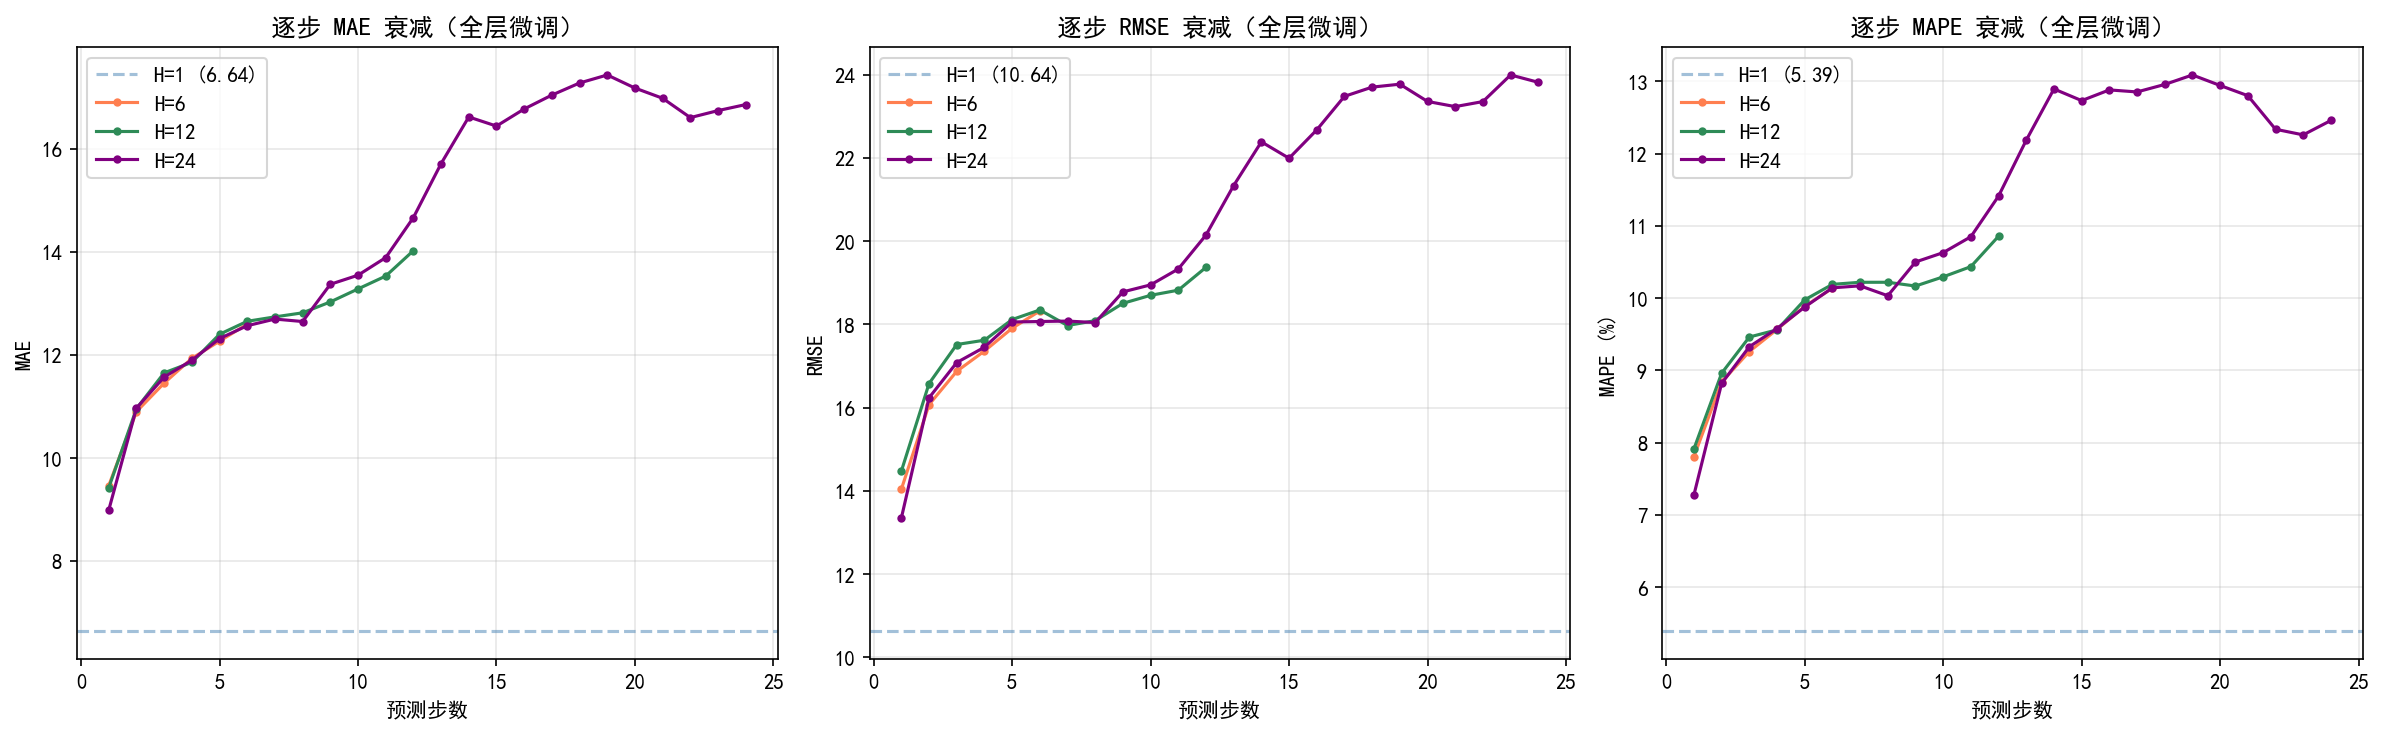

In [10]:
# 逐步精度衰减曲线（全层微调）
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_to_plot = ['MAE', 'RMSE', 'MAPE']
colors = {1: 'steelblue', 6: 'coral', 12: 'seagreen', 24: 'purple'}

for ax, metric in zip(axes, metrics_to_plot):
    for h in HORIZON_LIST:
        if h == 1:
            val = all_results[h]['full_fine_tune_per_step'].iloc[0][metric]
            ax.axhline(y=val, color=colors[h], linestyle='--', alpha=0.5,
                       label=f'H=1 ({val:.2f})')
        else:
            per_step = all_results[h]['full_fine_tune_per_step']
            ax.plot(per_step['step'], per_step[metric],
                    color=colors[h], marker='o', markersize=3, linewidth=1.5,
                    label=f'H={h}')

    ax.set_xlabel('预测步数')
    ax.set_ylabel(metric if metric != 'MAPE' else 'MAPE (%)')
    ax.set_title(f'逐步 {metric} 衰减（全层微调）')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '多步预测_逐步衰减.png', dpi=150, bbox_inches='tight')
plt.show()

### 3. 整体指标对比

整体指标将所有预测步合并计算。对于 `HORIZON>1` 的模型，整体指标包含远端预测步的贡献，因此可用于观察多步输出的总体稳定性。

In [6]:
# 整体指标对比表
overall_rows = []
for h in HORIZON_LIST:
    r = all_results[h]
    for strategy, metrics in [('目标域训练', r['target_train_overall']), ('全层微调', r['full_fine_tune_overall'])]:
        overall_rows.append({'HORIZON': h, '策略': strategy, **metrics})

overall_df = pd.DataFrame(overall_rows)
print("整体指标对比（所有预测步合并计算）")
print(overall_df.to_string(index=False, float_format='%.4f'))

整体指标对比（所有预测步合并计算）
 HORIZON    策略     MAE    RMSE  CV-RMSE    MAPE     R2
       1 目标域训练  9.6245 13.6721  11.5699  7.7352 0.8865
       1  全层微调  6.6396 10.6383   9.0026  5.3939 0.9313
       6 目标域训练 13.1761 18.8811  15.9778 10.3053 0.7818
       6  全层微调 11.4355 16.8242  14.2372  9.2493 0.8268
      12 目标域训练 13.9586 19.1224  16.2682 11.1823 0.7652
      12  全层微调 12.3636 17.8868  15.2170  9.8549 0.7945
      24 目标域训练 14.8538 19.4980  16.7121 12.2103 0.7442
      24  全层微调 14.6181 20.6579  17.7062 11.2925 0.7128


### 4. 目标域训练 vs 全层微调

验证在多步预测场景下，源域训练后的全层微调是否仍然优于只在目标域训练。

In [7]:
# 迁移学习提升幅度
improve_rows = []
for h in HORIZON_LIST:
    r = all_results[h]
    target_train = r['target_train_overall']
    full_fine_tune = r['full_fine_tune_overall']
    improve_rows.append({
        'HORIZON': h,
        'MAE提升': f"{(target_train['MAE'] - full_fine_tune['MAE']) / target_train['MAE'] * 100:.1f}%",
        'RMSE提升': f"{(target_train['RMSE'] - full_fine_tune['RMSE']) / target_train['RMSE'] * 100:.1f}%",
        'MAPE提升': f"{(target_train['MAPE'] - full_fine_tune['MAPE']) / target_train['MAPE'] * 100:.1f}%",
        'R2变化': f"{full_fine_tune['R2'] - target_train['R2']:.4f}",
    })

improve_df = pd.DataFrame(improve_rows)
print("全层微调 vs 目标域训练 提升幅度")
print(improve_df.to_string(index=False))

全层微调 vs 目标域训练 提升幅度
 HORIZON MAE提升 RMSE提升 MAPE提升    R2变化
       1 31.0%  22.2%  30.3%  0.0448
       6 13.2%  10.9%  10.2%  0.0449
      12 11.4%   6.5%  11.9%  0.0294
      24  1.6%  -5.9%   7.5% -0.0313


### 5. 保存结果

In [8]:
# 保存 Step-1 对比结果
step1_df.to_csv(BASE_DIR / 'multistep_step1_comparison.csv', index=False, encoding='utf-8-sig')

# 保存逐步衰减结果
per_step_all = []
for h in HORIZON_LIST:
    for strategy, key in [('目标域训练', 'target_train_per_step'), ('全层微调', 'full_fine_tune_per_step')]:
        df = all_results[h][key].copy()
        df.insert(0, '策略', strategy)
        df.insert(0, 'HORIZON', h)
        per_step_all.append(df)

per_step_all_df = pd.concat(per_step_all, ignore_index=True)
per_step_all_df.to_csv(BASE_DIR / 'multistep_per_step_results.csv', index=False, encoding='utf-8-sig')

print(f"Step-1 对比已保存: {BASE_DIR / 'multistep_step1_comparison.csv'}")
print(f"逐步衰减结果已保存: {BASE_DIR / 'multistep_per_step_results.csv'}")

Step-1 对比已保存: data\multistep_step1_comparison.csv
逐步衰减结果已保存: data\multistep_per_step_results.csv
